# 08 — Feature Importance

Two stories told by the per-fold `feature_status.csv` log:

1. **L1 selection** — for Lasso and ElasticNet, the `retained` flag is binary (the L1 penalty zeroed the coefficient or not). Which features survive selection, and how stable is that selection across the 5 folds?
2. **Tree importance** — for RF and XGBoost, every feature is retained, but the model's built-in importance score (`gini` for RF, `gain` for XGBoost) reveals which features drove the splits.

Inputs (controlled by `FILE_PREFIX`):
- `results/logs/{prefix}feature_status.csv` — `(fold, lead, model, feature, importance, retained, kind)`
- `results/logs/{prefix}fold_runs.csv` — best HPs and per-fold counts (for context)

Sections:
1. ElasticNet / Lasso feature retention across folds — heatmap (feature × lead).
2. Top retained features per lead — bar charts.
3. RF feature importance (Gini), top-15 per lead — bar charts.
4. XGBoost feature importance (gain), top-15 per lead — bar charts.
5. RF vs XGBoost — feature-importance scatter at the headline lead.

Figures saved to `results/figures/08_feature_importance/`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

from droughtmodel.utils import save_figure, RESULTS_DIR

# Switch to '' when the production sweep finishes
FILE_PREFIX = ''
FIG_SUBDIR = '08_feature_importance'

feat = pd.read_csv(RESULTS_DIR / 'logs' / f'{FILE_PREFIX}feature_status.csv')
runs = pd.read_csv(RESULTS_DIR / 'logs' / f'{FILE_PREFIX}fold_runs.csv')

TOP_N = 15
HEADLINE_LEAD = 3 if 3 in feat['lead'].unique() else int(feat['lead'].median())
LINEAR_L1 = ['lasso', 'elasticnet']
TREE_MODELS = ['rf', 'xgboost']

print(f'rows: {len(feat)}  |  models: {sorted(feat["model"].unique())}  |  leads: {sorted(feat["lead"].unique())}')
print(f'feature count: {feat["feature"].nunique()}')
print(f'headline lead: {HEADLINE_LEAD}')
print(f'\nkind tally:')
print(feat.groupby('model')['kind'].first())

rows: 5409  |  models: ['ar', 'elasticnet', 'lasso', 'ols', 'rf', 'ridge', 'xgboost']  |  leads: [np.int64(1), np.int64(3), np.int64(6)]
feature count: 63
headline lead: 3

kind tally:
model
ar            none
elasticnet    coef
lasso         coef
ols           coef
rf            gini
ridge         coef
xgboost       gain
Name: kind, dtype: str


## 1. L1 feature retention across folds

For each (model in {lasso, elasticnet}, lead, feature): count how many of the 5 folds kept that feature (non-zero coefficient at the best HP). Stability ranges from 0 (always dropped) to 5 (always kept). The heatmaps below sort features by their retention count at the headline lead so the most stable features land at the top.

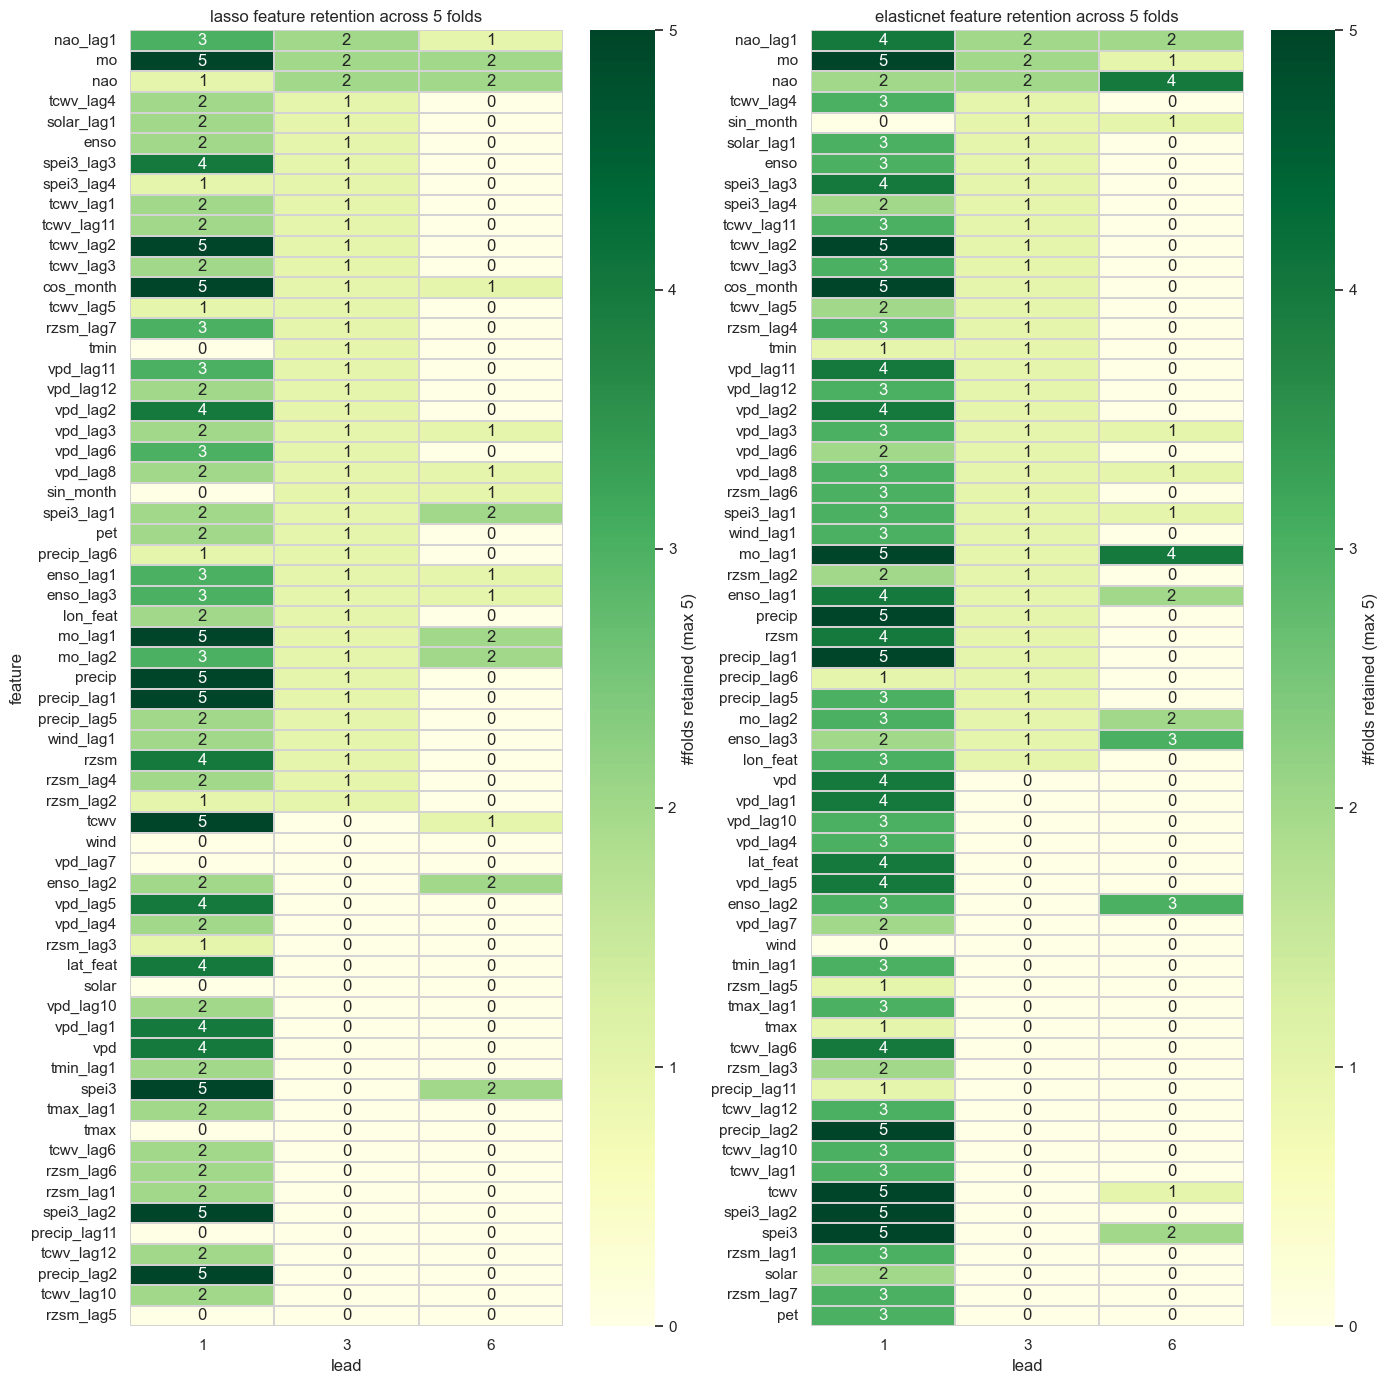


Features fully retained (kept in all 5 folds) per (model, lead):
  lasso       L=1:  10 always-kept |   8 always-dropped |  45 mixed
  lasso       L=3:   0 always-kept |  25 always-dropped |  38 mixed
  lasso       L=6:   0 always-kept |  48 always-dropped |  15 mixed
  elasticnet  L=1:  10 always-kept |   2 always-dropped |  51 mixed
  elasticnet  L=3:   0 always-kept |  27 always-dropped |  36 mixed
  elasticnet  L=6:   0 always-kept |  49 always-dropped |  14 mixed


In [2]:
n_folds = feat[feat['kind'] == 'coef']['fold'].nunique()

fig, axes = plt.subplots(1, len(LINEAR_L1), figsize=(7 * len(LINEAR_L1), 14), sharey=False)
for ax, mdl in zip(axes, LINEAR_L1):
    sub = feat[feat['model'] == mdl]
    if sub.empty:
        ax.text(0.5, 0.5, f'{mdl}: no rows', ha='center')
        continue
    # retention count per (lead, feature)
    counts = (sub.assign(retained_int=sub['retained'].astype(int))
                 .groupby(['feature', 'lead'])['retained_int']
                 .sum()
                 .unstack('lead', fill_value=0))
    # Sort features by retention at the headline lead, descending
    sort_key = counts[HEADLINE_LEAD] if HEADLINE_LEAD in counts.columns else counts.iloc[:, 0]
    counts = counts.loc[sort_key.sort_values(ascending=False).index]
    sns.heatmap(
        counts, ax=ax, cmap='YlGn', vmin=0, vmax=n_folds,
        cbar_kws={'label': f'#folds retained (max {n_folds})'},
        annot=True, fmt='d', linewidths=0.3, linecolor='lightgray',
    )
    ax.set_title(f'{mdl} feature retention across {n_folds} folds')
    ax.set_xlabel('lead')
    ax.set_ylabel('feature' if mdl == LINEAR_L1[0] else '')

plt.tight_layout()
save_figure(fig, 'l1_retention_heatmap', subdir=FIG_SUBDIR)
plt.show()

# Quick numerical summary
print(f'\nFeatures fully retained (kept in all {n_folds} folds) per (model, lead):')
for mdl in LINEAR_L1:
    for L in sorted(feat['lead'].unique()):
        sub = feat.query("model == @mdl and lead == @L")
        if sub.empty:
            continue
        retention = sub.groupby('feature')['retained'].sum()
        always_kept = retention[retention == n_folds].index.tolist()
        never_kept = retention[retention == 0].index.tolist()
        print(f'  {mdl:11s} L={L}: {len(always_kept):>3d} always-kept | '
              f'{len(never_kept):>3d} always-dropped | '
              f'{sub["feature"].nunique() - len(always_kept) - len(never_kept):>3d} mixed')

## 2. Top retained features by mean |coefficient|

Among the features kept by Lasso / ElasticNet, which have the largest standardized coefficient (averaged over the folds that retained them)? Features are pre-standardized in the pipeline, so coefficients are directly comparable as standardized contributions.

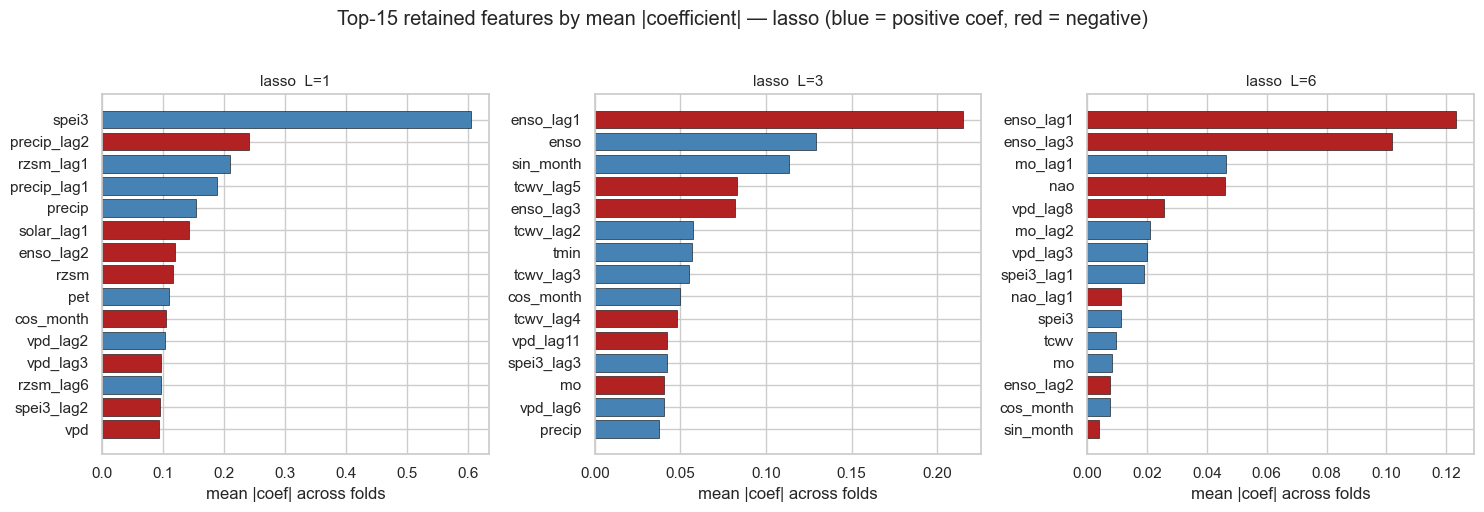

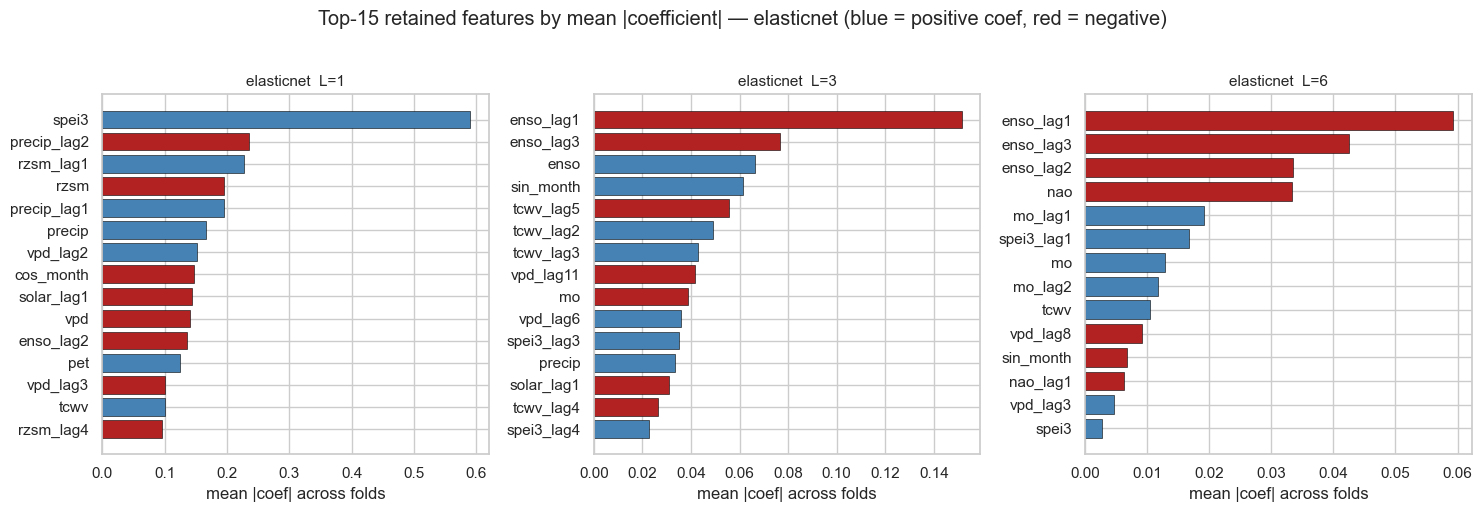

In [3]:
def _top_coef_features(mdl: str, lead: int, top_n: int = TOP_N) -> pd.DataFrame:
    sub = feat.query("model == @mdl and lead == @lead and retained")
    if sub.empty:
        return sub
    return (sub.assign(abs_coef=sub['importance'].abs())
              .groupby('feature')
              .agg(mean_abs_coef=('abs_coef', 'mean'),
                   mean_signed=('importance', 'mean'),
                   n_folds_retained=('retained', 'sum'))
              .sort_values('mean_abs_coef', ascending=False)
              .head(top_n))

for mdl in LINEAR_L1:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    for ax, L in zip(axes, sorted(feat['lead'].unique())):
        top = _top_coef_features(mdl, L)
        if top.empty:
            ax.text(0.5, 0.5, f'no retained features at L={L}', ha='center'); continue
        colors = ['steelblue' if c >= 0 else 'firebrick' for c in top['mean_signed']]
        ax.barh(top.index[::-1], top['mean_abs_coef'][::-1], color=colors[::-1], edgecolor='black', linewidth=0.4)
        ax.set_title(f'{mdl}  L={L}', fontsize=11)
        ax.set_xlabel('mean |coef| across folds')
    fig.suptitle(f'Top-{TOP_N} retained features by mean |coefficient| — {mdl} '
                 '(blue = positive coef, red = negative)', y=1.02)
    plt.tight_layout()
    save_figure(fig, f'top_features_{mdl}', subdir=FIG_SUBDIR)
    plt.show()

## 3. Random Forest feature importance (Gini)

Top-15 features per lead by mean Gini importance across folds. Trees retain all features by design (no L1 selection), so this ranks by *splitting utility* rather than presence/absence.

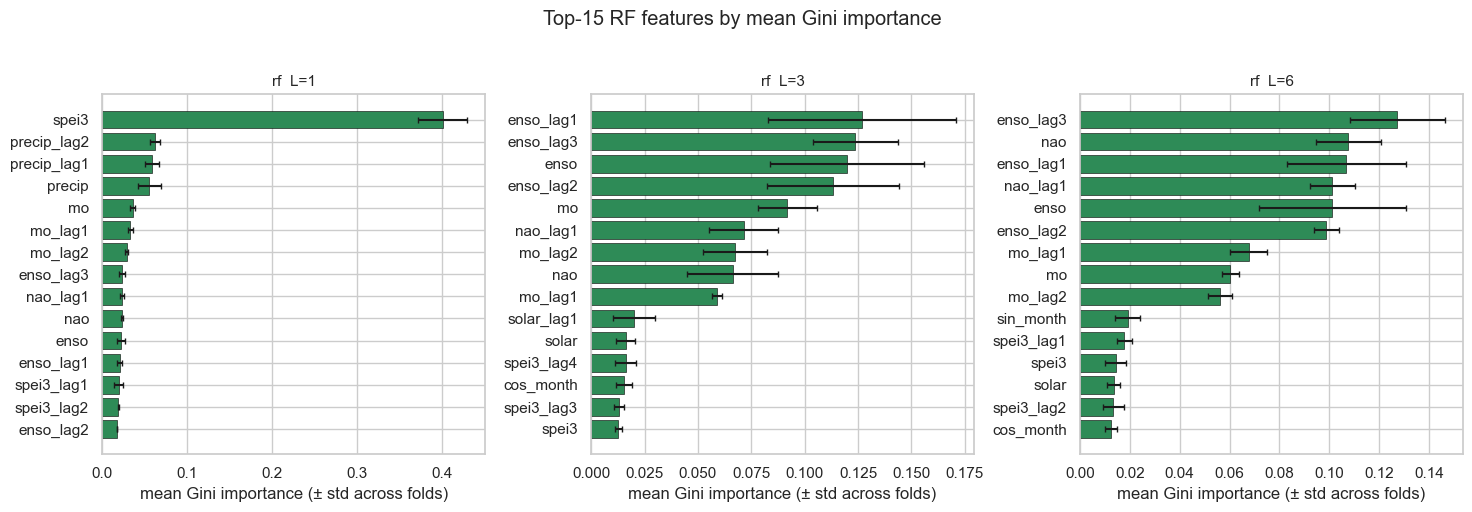

In [4]:
def _top_tree_features(mdl: str, lead: int, top_n: int = TOP_N) -> pd.DataFrame:
    sub = feat.query("model == @mdl and lead == @lead")
    if sub.empty:
        return sub
    return (sub.groupby('feature')
              .agg(mean_importance=('importance', 'mean'),
                   std_importance=('importance', 'std'))
              .sort_values('mean_importance', ascending=False)
              .head(top_n))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, L in zip(axes, sorted(feat['lead'].unique())):
    top = _top_tree_features('rf', L)
    if top.empty:
        ax.text(0.5, 0.5, f'no rf rows at L={L}', ha='center'); continue
    ax.barh(top.index[::-1], top['mean_importance'][::-1],
            xerr=top['std_importance'][::-1],
            color='seagreen', edgecolor='black', linewidth=0.4, capsize=2)
    ax.set_title(f'rf  L={L}', fontsize=11)
    ax.set_xlabel('mean Gini importance (± std across folds)')
fig.suptitle(f'Top-{TOP_N} RF features by mean Gini importance', y=1.02)
plt.tight_layout()
save_figure(fig, 'top_features_rf', subdir=FIG_SUBDIR)
plt.show()

## 4. XGBoost feature importance (gain)

Same view for XGBoost. The default importance type in modern xgboost is `gain` — the total improvement in loss attributable to splits on that feature.

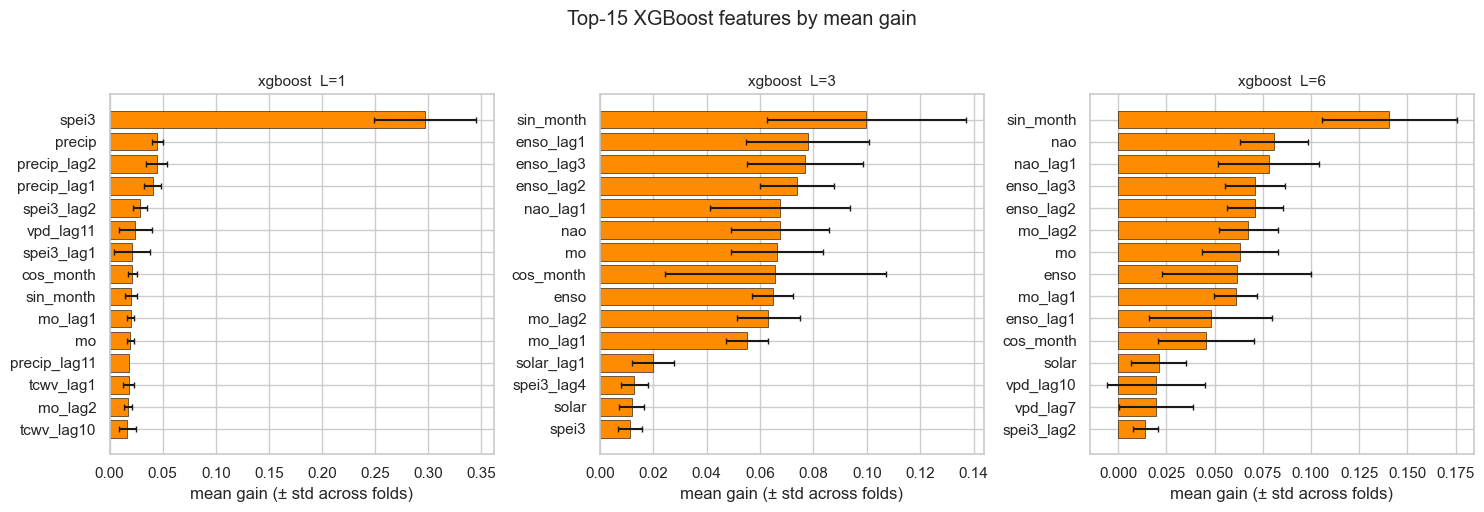

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, L in zip(axes, sorted(feat['lead'].unique())):
    top = _top_tree_features('xgboost', L)
    if top.empty:
        ax.text(0.5, 0.5, f'no xgboost rows at L={L}', ha='center'); continue
    ax.barh(top.index[::-1], top['mean_importance'][::-1],
            xerr=top['std_importance'][::-1],
            color='darkorange', edgecolor='black', linewidth=0.4, capsize=2)
    ax.set_title(f'xgboost  L={L}', fontsize=11)
    ax.set_xlabel('mean gain (± std across folds)')
fig.suptitle(f'Top-{TOP_N} XGBoost features by mean gain', y=1.02)
plt.tight_layout()
save_figure(fig, 'top_features_xgboost', subdir=FIG_SUBDIR)
plt.show()

## 5. RF vs XGBoost — do the two trees agree?

Per-feature mean importance, RF (x-axis) vs XGBoost (y-axis), at the headline lead. Diagonal = perfect agreement.

Features in the **top-right corner** are agreed-important — both models rely on them. Features **far off-diagonal** indicate where the two ensemble strategies disagree on what matters (often a hint that the feature is redundant with others through one model's lens but not the other's).

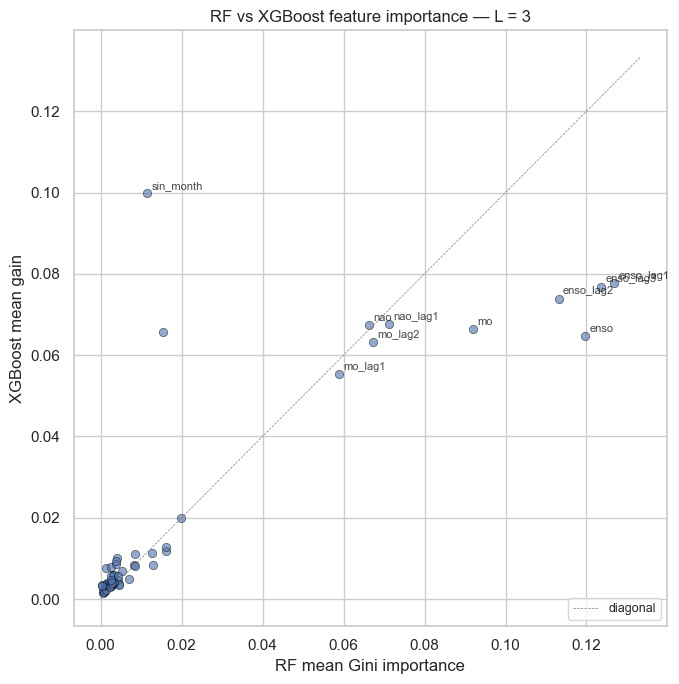

Spearman rank correlation between RF and XGBoost importance at L=3: +0.886


In [6]:
L = HEADLINE_LEAD
rf_imp = feat.query("model == 'rf' and lead == @L").groupby('feature')['importance'].mean()
xgb_imp = feat.query("model == 'xgboost' and lead == @L").groupby('feature')['importance'].mean()

common = rf_imp.index.intersection(xgb_imp.index)
if len(common) == 0:
    print('no overlap between RF and XGBoost feature sets at the headline lead — skipping')
else:
    df = pd.DataFrame({'rf': rf_imp.loc[common], 'xgboost': xgb_imp.loc[common]})

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(df['rf'], df['xgboost'], alpha=0.6, edgecolor='black', linewidth=0.5)
    # Annotate the top-N by mean rank
    df['mean_rank'] = (df['rf'].rank(ascending=False) + df['xgboost'].rank(ascending=False)) / 2
    for feat_name in df.nsmallest(10, 'mean_rank').index:
        ax.annotate(feat_name, (df.loc[feat_name, 'rf'], df.loc[feat_name, 'xgboost']),
                    fontsize=8, alpha=0.85, xytext=(3, 3), textcoords='offset points')
    lim = max(df['rf'].max(), df['xgboost'].max()) * 1.05
    ax.plot([0, lim], [0, lim], color='gray', linewidth=0.5, linestyle='--', label='diagonal')
    ax.set_xlabel('RF mean Gini importance')
    ax.set_ylabel('XGBoost mean gain')
    ax.set_title(f'RF vs XGBoost feature importance — L = {L}')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    save_figure(fig, f'rf_vs_xgboost_scatter_L{L}', subdir=FIG_SUBDIR)
    plt.show()

    # Spearman rank correlation
    rho = df[['rf', 'xgboost']].corr(method='spearman').iloc[0, 1]
    print(f'Spearman rank correlation between RF and XGBoost importance at L={L}: {rho:+.3f}')

## Notes

- **Importance kind**: linear models report standardized coefficients (`kind='coef'`); RF reports Gini importance (`kind='gini'`); XGBoost reports gain (`kind='gain'`). These are *built-in* importances — fast to extract but each has known biases.
- **Caveat (multicollinearity, see notebook §6/`selection.py` docstring)**: built-in tree importances distribute credit unevenly across correlated features. To get the *fair*-credit ranking, compute **permutation importance** (RF) and **TreeSHAP** (XGBoost) on the OOS test slice. The helpers exist in `droughtmodel/selection.py` but require a fitted model + the test feature matrix — currently the pipeline doesn't save fitted models, so adding permutation/SHAP rows to `feature_status.csv` is a pipeline enhancement we'd queue for a Phase 12-style polish.
- **What to look for in the production run**: with `n_trials=40` on the full sweep, expect tighter / more stable feature rankings (current smoke's `n_trials=5` lets randomness dominate). The L1 retention heatmap is the most direct visual diagnostic for that stability — features that stay green at L=3 across all 5 folds are the ones the paper can confidently claim are important.
- **Swap to production**: change `FILE_PREFIX = 'testOptuna_'` → `''` and re-run.